<a href="https://colab.research.google.com/github/AnzorGozalishvili/IOAI-2025-lectures/blob/main/lecture_31_transformers_finetuning_on_classification/notebooks/Arseniy_Sandalov_GeorgianBert_Sent_Analyzing_Model_Performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Arseniy-Sandalov/GeorgianBert-Sent

- Model Card: https://huggingface.co/Arseniy-Sandalov/GeorgianBert-Sent
- Sentiment Dataset Source: https://data.jrc.ec.europa.eu/dataset/9f04066a-8cc0-4669-99b4-f1f0627fdbbf
- dataset on huggingface: https://huggingface.co/datasets/Arseniy-Sandalov/Georgian-Sentiment-Analysis

### class label map
- https://huggingface.co/Arseniy-Sandalov/GeorgianBert-Sent/blob/main/config.json

```json
{
  "0": "Mixed",
  "1": "Positive",
  "2": "Neutral",
  "3": "Negative"
}
```

In [108]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch

model_name = "Arseniy-Sandalov/GeorgianBert-Sent"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

CLASSES = ['Mixed', 'Positive', 'Neutral', 'Negative']

# Move the model to the GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

def predict_sentiment(text):
    model.eval()
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)
    # Move input tensors to the GPU
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
    predictions = outputs.logits.argmax(dim=1).cpu().tolist()
    return [CLASSES[prediction] for prediction in predictions]

text = "ახალი მეარი კარგია ერთილა"
print(predict_sentiment([text, text, text]))

['Positive', 'Positive', 'Positive']


# Evaluate on Sentiment Dataset

In [33]:
!pip install datasets

## Load Dataset

In [100]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("Arseniy-Sandalov/Georgian-Sentiment-Analysis")
filtered_dataset = dataset.filter(lambda example: example['sentiment'] in CLASSES)
print(dataset, filtered_dataset)
pd.Series(filtered_dataset['train']['sentiment']).value_counts()

DatasetDict({
    train: Dataset({
        features: ['text', 'sentiment', 'perturbation'],
        num_rows: 4219
    })
}) DatasetDict({
    train: Dataset({
        features: ['text', 'sentiment', 'perturbation'],
        num_rows: 4219
    })
})


,count
Neutral,1731
Negative,1417
Positive,765
Mixed,306


## Evaluate

In [101]:
from torch.utils.data import DataLoader, TensorDataset

label_to_id = {k:idx for idx,k in enumerate(CLASSES)}
id_to_label = {idx:k for idx,k in enumerate(CLASSES)}

def create_dataloader(dataset, tokenizer, batch_size=32, max_length=512):
    texts = [example['text'] for example in dataset]
    labels = [example['sentiment'] for example in dataset]  # Assuming 'label' key exists
    label_ids = [label_to_id[label] for label in labels]

    # Tokenize the texts
    encoded_inputs = tokenizer(texts, truncation=True, padding='max_length', max_length=max_length, return_tensors='pt')

    # Create TensorDataset
    dataset = TensorDataset(encoded_inputs['input_ids'], encoded_inputs['attention_mask'], torch.tensor(label_ids))

    # Create DataLoader
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False) # Set shuffle=False for inference

    return dataloader


# Example Usage
batch_size = 256  # Adjust as needed
dataloader = create_dataloader(filtered_dataset['train'], tokenizer, batch_size=batch_size) # Use 'test' split

In [102]:
next(iter(dataloader))

[tensor([[   101,  21054, 111514,  ...,      0,      0,      0],
         [   101,   1573,  15812,  ...,      0,      0,      0],
         [   101,  53369,  22329,  ...,      0,      0,      0],
         ...,
         [   101,  30537,  12509,  ...,      0,      0,      0],
         [   101,  52821,  25579,  ...,      0,      0,      0],
         [   101,   1566,  23871,  ...,      0,      0,      0]]),
 tensor([[1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         ...,
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0]]),
 tensor([2, 0, 3, 1, 3, 1, 1, 1, 3, 2, 1, 1, 1, 0, 2, 3, 0, 1, 0, 1, 1, 1, 1, 3,
         0, 0, 3, 3, 3, 0, 3, 1, 1, 0, 1, 3, 0, 0, 3, 0, 3, 3, 2, 0, 0, 1, 0, 0,
         3, 3, 0, 3, 0, 1, 1, 1, 1, 0, 0, 0, 3, 1, 1, 0, 2, 3, 0, 0, 2, 0, 0, 3,
         2, 0, 0, 3, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
         3, 0, 3, 0, 0, 0, 0, 0, 0, 0, 2, 1,

In [111]:
def predict_batch(batch, model):
    model.eval()
    input_ids, attention_mask, labels = batch
    with torch.no_grad():
        # Move inputs to the device
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predictions = outputs.logits.argmax(dim=1).cpu().tolist()
        probabilities = outputs.logits.softmax(dim=1).cpu().tolist()
        labels = labels.tolist()

    return predictions, probabilities, labels

batch_preds, batch_probs, batch_labels = predict_batch(batch=next(iter(dataloader)), model=model)
print(batch_preds[:10], batch_probs[:10], batch_labels[:10])

[2, 3, 1, 2, 3, 2, 2, 2, 3, 1] [[0.0011812029406428337, 0.0012617252068594098, 0.9959084987640381, 0.0016486651729792356], [0.006221230141818523, 0.0030805182177573442, 0.005633937194943428, 0.9850643277168274], [0.022548705339431763, 0.9382203817367554, 0.031763214617967606, 0.007467684801667929], [0.0014885448617860675, 0.0016623014817014337, 0.9951386451721191, 0.0017104101134464145], [0.025022972375154495, 0.004544307943433523, 0.03482918441295624, 0.9356034994125366], [0.0011074967915192246, 0.0014305391814559698, 0.9959994554519653, 0.001462498214095831], [0.0011153612285852432, 0.0013600060483440757, 0.9961073994636536, 0.00141717039514333], [0.0012095128186047077, 0.002136952243745327, 0.9954127669334412, 0.0012408100301399827], [0.14085941016674042, 0.021693814545869827, 0.04842132702469826, 0.7890254855155945], [0.0042004273273050785, 0.9878742098808289, 0.004265500232577324, 0.0036598050501197577]] [2, 0, 3, 1, 3, 1, 1, 1, 3, 2]


In [104]:
from tqdm import tqdm

def batch_predict_sentiment(dataloader, model):
    all_predictions = []
    all_probabilities = []
    all_labels = []

    for batch in tqdm(dataloader):
        predictions, probabilities, labels = predict_batch(batch, model)

        all_predictions.extend(predictions)
        all_labels.extend(labels)
        all_probabilities.extend(probabilities)

    return all_predictions, all_probabilities, all_labels

predictions, probabilities, labels = batch_predict_sentiment(dataloader, model)

100%|██████████| 17/17 [04:15<00:00, 15.00s/it]


In [114]:
# NOTE: there is an error in model outputs and we need to reverse true labels
labels_2 = [{0:3, 1:2, 2:1, 3:0}[x] for x in labels]

              precision    recall  f1-score   support

       Mixed       0.71      0.17      0.27       306
    Positive       0.84      0.84      0.84       765
     Neutral       0.88      0.88      0.88      1731
    Negative       0.77      0.90      0.83      1417

    accuracy                           0.83      4219
   macro avg       0.80      0.70      0.71      4219
weighted avg       0.82      0.83      0.81      4219



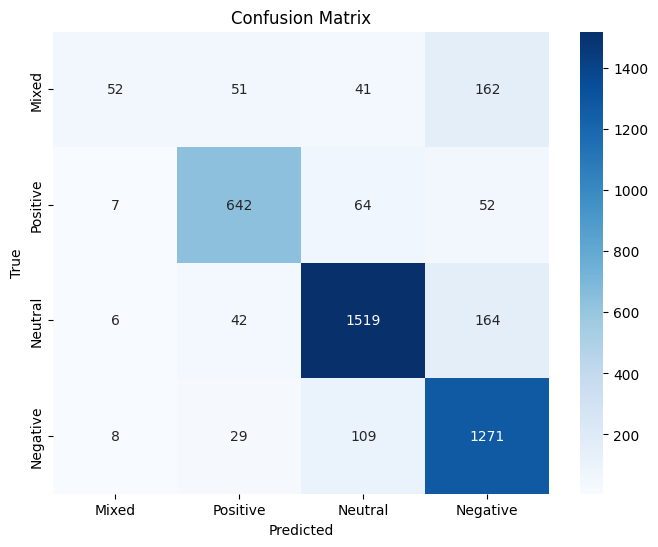

Macro F1-Score: 0.7050712377040173
AUC-ROC (OVO, macro): 0.9265264847099333


In [115]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

def classification_reports(true_labels, predicted_labels, predicted_probabilities):

    # Classification Report
    print(classification_report(true_labels, predicted_labels, target_names=CLASSES))

    # Confusion Matrix
    cm = confusion_matrix(true_labels, predicted_labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASSES,
                yticklabels=CLASSES)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

    # F1-Score (macro average)
    f1 = f1_score(true_labels, predicted_labels, average='macro')
    print(f"Macro F1-Score: {f1}")


    # AUC-ROC (requires probabilities)
    try:
        auc_roc = roc_auc_score(np.eye(4)[true_labels], np.array(predicted_probabilities), multi_class='ovo', average='macro')
        print(f"AUC-ROC (OVO, macro): {auc_roc}")
    except ValueError as e:
        print(f"AUC-ROC Calculation failed: {e}")

classification_reports(true_labels=labels_2, predicted_labels=predictions, predicted_probabilities=probabilities)


# ML Model Results From Paper

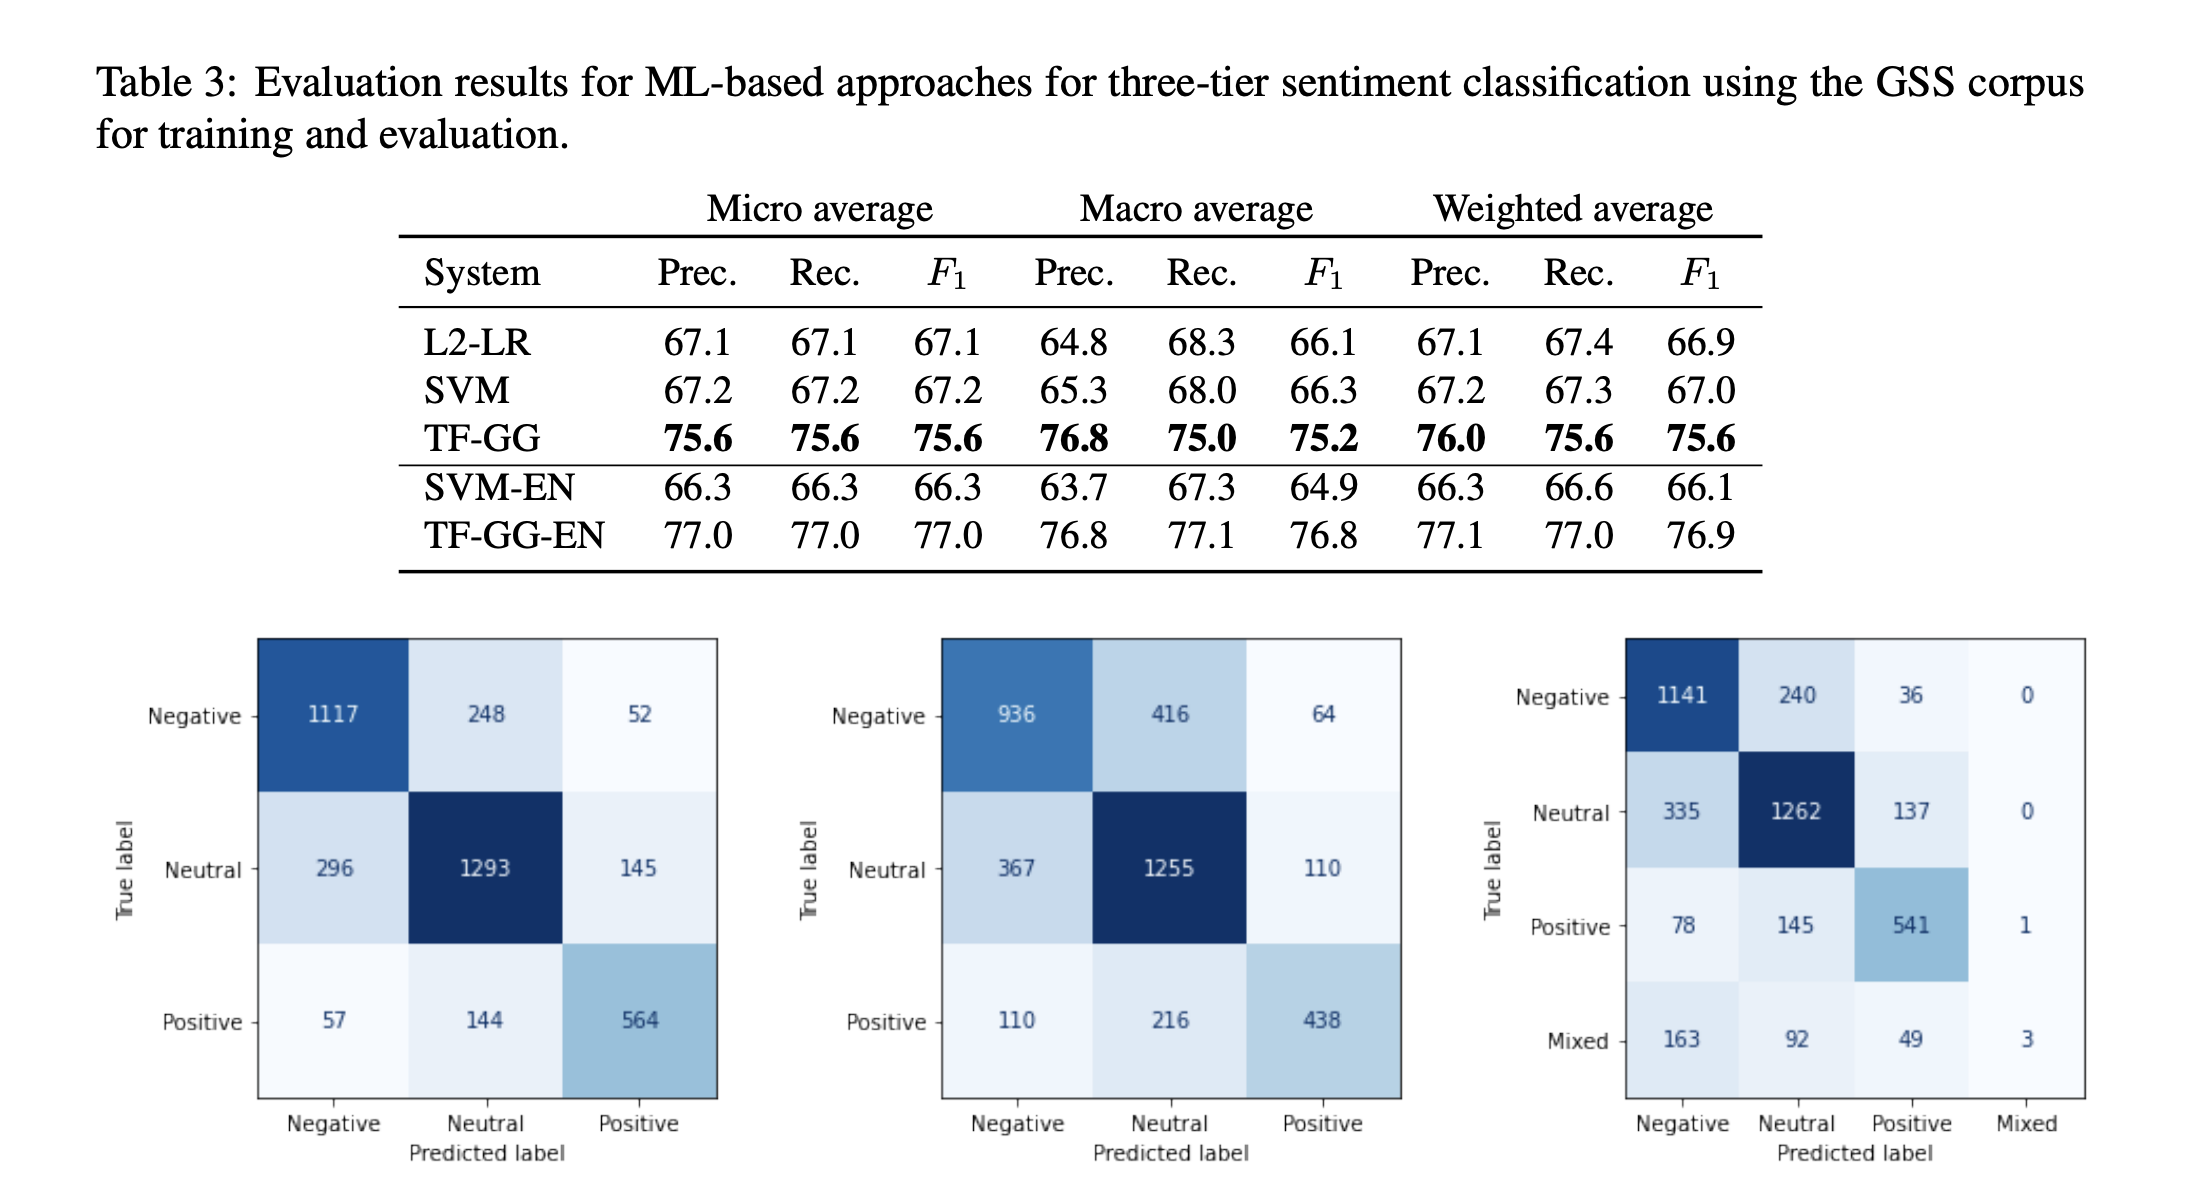


# Let's explore Georgian vocabulary and how it tokenizes text

The statistics of our interest:
- total Georgian tokens
- percentage of Georgian tokens in full vocab
- average Georgian token length vs Latin Token lengths
- average token length in our dataset

In [116]:
import re

georgian_alphabet = "აბგდევზთიკლმნოპჟრსტუფქღყშჩცძწჭხჯჰ"
latin_alphabet = "abcdefghijklmnopqrstuvwxyz"

def is_georgian(token):
  return bool(re.search(f"[{georgian_alphabet}]", token))

def is_latin(token):
  return bool(re.search(f"[{latin_alphabet}]", token))


georgian_tokens = 0
latin_tokens = 0
georgian_token_lengths = []
latin_token_lengths = []
all_token_lengths = []

for token in tokenizer.vocab:
  all_token_lengths.append(len(token))
  if is_georgian(token):
    georgian_tokens +=1
    georgian_token_lengths.append(len(token))
  elif is_latin(token):
    latin_tokens += 1
    latin_token_lengths.append(len(token))


print(f"Total Georgian tokens: {georgian_tokens}")
print(f"Percentage of Georgian tokens in full vocab: {(georgian_tokens / len(tokenizer.vocab)) * 100:.2f}%")

if georgian_token_lengths:
    avg_georgian_token_length = sum(georgian_token_lengths) / len(georgian_token_lengths)
else:
    avg_georgian_token_length = 0

if latin_token_lengths:
    avg_latin_token_length = sum(latin_token_lengths) / len(latin_token_lengths)
else:
    avg_latin_token_length = 0

print(f"Average Georgian token length: {avg_georgian_token_length:.2f}")
print(f"Average Latin token length: {avg_latin_token_length:.2f}")

avg_token_length_dataset = sum(all_token_lengths) / len(all_token_lengths)
print(f"Average token length in the tokenizer vocab: {avg_token_length_dataset:.2f}")


Total Georgian tokens: 703
Percentage of Georgian tokens in full vocab: 0.59%
Average Georgian token length: 5.44
Average Latin token length: 6.46
Average token length in the tokenizer vocab: 5.39


In [117]:
# prompt: average token length in our dataset

avg_token_length_dataset = sum(all_token_lengths) / len(all_token_lengths)
print(f"Average token length in the tokenizer vocabulary: {avg_token_length_dataset:.2f}")

token_lengths_in_dataset = []
for example in filtered_dataset['train']:
    tokens = tokenizer.tokenize(example['text'])
    token_lengths_in_dataset.extend([len(token) for token in tokens])

avg_token_length_in_dataset = sum(token_lengths_in_dataset) / len(token_lengths_in_dataset) if token_lengths_in_dataset else 0

print(f"Average token length in the dataset: {avg_token_length_in_dataset:.2f}")


Average token length in the tokenizer vocabulary: 5.39
Average token length in the dataset: 3.33


In [118]:
# prompt: Show 100 examples of tokenized text. print full text and then tokens comma separated

example_texts = filtered_dataset['train']['text'][:100]

for text in example_texts:
  tokens = tokenizer.tokenize(text)
  print(text)
  print(*tokens, sep=", ")
  print("---")

ამჟამად, სამაშველო და სტიქიის შედეგების სალიკვიდაციო სამუშაოები მიმდინარეობს, რომელშიც მერიის სამსახურებთან და შსს-ის დანაყოფებთან ერთად ასევე ჩართულია თავდაცვის სამინისტროს პირადი შემადგენლობა
ამ, ##ჟ, ##ამ, ##ად, ,, ს, ##ამ, ##ა, ##შ, ##ველო, და, ს, ##ტი, ##ქი, ##ის, შ, ##ე, ##დე, ##გ, ##ების, ს, ##ალი, ##კ, ##ვიდა, ##ც, ##იო, ს, ##ამ, ##უ, ##შა, ##ო, ##ები, მ, ##ი, ##მ, ##დი, ##ნა, ##რე, ##ობს, ,, რომ, ##ელში, ##ც, მე, ##რი, ##ის, ს, ##ამ, ##სა, ##ხ, ##ურ, ##ე, ##ბთან, და, შ, ##ს, ##ს, -, ის, და, ##ნა, ##ყო, ##ფ, ##ე, ##ბთან, ერთად, ასევე, ჩ, ##არ, ##თ, ##ულია, თ, ##ა, ##ვდა, ##ც, ##ვის, სამი, ##ნის, ##ტ, ##როს, პ, ##ი, ##რად, ##ი, შ, ##ემა, ##დ, ##გ, ##ენ, ##ლობა
---
კომპანიას უკვე მეორე დღეა თავის Facebookის გვერდზე უამრავი შეურაცხმყოფელი კომენტარით ამკობენ გაბრაზებული გულშემატკივრები
კ, ##ო, ##მ, ##პ, ##ანი, ##ას, უკვე, მეორე, დ, ##ღ, ##ე, ##ა, თავის, Facebook, ##ის, გვ, ##ერ, ##დ, ##ზე, უ, ##ამ, ##რა, ##ვი, შ, ##ე, ##ურ, ##აც, ##ხ, ##მ, ##ყო, ##ფ, ##ელი, კ, ##ო, ##მე, ##ნ, ##ტა,